##Quantum Classifier

In [1]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.gradients import ParamShiftEstimatorGradient
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import EstimatorQNN
import numpy as np
import torch.nn as nn
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score, accuracy_score


import sys          # Standard library module for system-specific parameters and functions
import subprocess   # Standard library module for spawning new processes
from sklearn.preprocessing import MinMaxScaler # Importuje MinMaxScaler do skalowania danych
from sklearn.model_selection import train_test_split # Importuje train_test_split do podziału danych
from ucimlrepo import fetch_ucirepo     # Importuje fetch_ucirepo do pobierania zestawów danych z UCI ML Repository
from sklearn.utils import shuffle

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score


from sklearn.model_selection import KFold


In [2]:
def ensure_package(pkg_name, import_name=None):
    import_name = import_name or pkg_name
    try:
        __import__(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg_name])

# Ensure all requirements are met
ensure_package('numpy')
ensure_package('scikit-learn', 'sklearn')
ensure_package('ucimlrepo')
ensure_package('qiskit')

def prepare_data():
    """
    Fetches the banknote authentication dataset and returns scaled train/test splits.
    Features are scaled to [0, pi] specifically for Angle Encoding.
    """
    banknote_authentication = fetch_ucirepo(id=267)
    X = banknote_authentication.data.features.to_numpy()
    y = banknote_authentication.data.targets.to_numpy().ravel()

    variance = X[:, 0].reshape(-1, 1)
    skewness = X[:, 1].reshape(-1, 1)

    interaction = skewness * variance
    X_expanded = np.hstack((X, interaction))

    X_train, X_test, y_train, y_test = train_test_split(X_expanded, y, test_size=0.2, random_state=42)

    scaler = MinMaxScaler(feature_range=(0, np.pi))
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test


# Global availability of data
X_tr, X_te, y_tr, y_te = prepare_data()

In [3]:
def ansatz(n_qubits, depth):
    """
    Ansatz with Ring topology.
    Uses exclusively native-like gates: Rx, Ry, Rz, and Cz.
    No Hadamard or CX gates are used.
    """
    # For each full iteration (2 layers):
    # Layer 1: n_qubits (Ry) + n_qubits (Rz before Cz)
    # Layer 2: n_qubits (Rx) + n_qubits (Ry before Cz)
    # Total: 4 * n_qubits per iteration (depth // 2 iterations)
    params_per_iter = 4 * n_qubits
    theta = ParameterVector('θ', params_per_iter * (depth // 2))

    qc = QuantumCircuit(n_qubits)

    for j in range(depth // 2):
        offset = j * params_per_iter

        # -------- Layer 1: Ry + Ring Cz (with Rz) --------

        # 1. Independent Ry rotations
        for i in range(n_qubits):
            qc.ry(theta[offset + i], i)

        # 2. Ring entanglement (0-1, 1-2, ..., n-1-0)
        # Each pair: Rz on target + Cz
        for i in range(n_qubits):
            control = i
            target = (i + 1) % n_qubits

            param_idx = offset + n_qubits + i
            qc.rz(theta[param_idx], target)
            qc.cz(control, target)

        # -------- Layer 2: Rx + Ring Cz (with Ry) --------

        offset_l2 = offset + 2 * n_qubits

        # 1. Independent Rx rotations
        for i in range(n_qubits):
            qc.rx(theta[offset_l2 + i], i)

        # 2. Reverse ring entanglement (or shifted)
        # Each pair: Ry on target + Cz
        for i in range(n_qubits):
            control = i
            target = (i - 1) % n_qubits

            param_idx = offset_l2 + n_qubits + i
            qc.ry(theta[param_idx], target)
            qc.cz(control, target)

    return qc

In [4]:
"""
    The code below constructs the class HybridModel. It is built using the Qiskit and Pytorch library and
    and utilizes its built-in tools, to create a model connecting classical and quantum computing.

"""

class HybridModel(nn.Module):
    def __init__(self, ansatz_circuit, num_qubits):
        super().__init__()
        self.feature_map = self.angle_encoding(num_qubits)

        # Connecting the quantum circuit. Connecting our feature map (data) and ansatz
        self.qc = QuantumCircuit(num_qubits)
        self.qc.compose(self.feature_map, qubits=range(num_qubits), inplace=True)
        self.qc.compose(ansatz_circuit, inplace=True)

        # Firstly, we inicialize parameters. Our quantum model cannot tell whether the number came from ansatz or feature.
        # That is why here we sort them into two lists. If the number came from feature_map, then it will be a feature and the other way around.
        input_params = list(self.feature_map.parameters)
        weight_params = list(ansatz_circuit.parameters)

        '''
        Measure the Z-operator (spin) on the very first qubit (q_0) and ignore all the other qubits.
        Qiskit reads the string in a reversed order, that is why the Z gate is on the end.
        SparsePauliOp.from_list([("I" * (num_qubits - 1) + "Z", 1)]) converts string into a mathematical matrix that Qiskit can use for calculations
        Coefficient = 1 is a weight we multiply our result by. In QML it is mostly set to 1
        '''

        observable = SparsePauliOp.from_list([("I" * (num_qubits - 1) + "Z", 1)])

        # Estimator takes ansatz, observables and parameters (data and weights), returns the Expectation value.
        # !!!! CHANGE WHEN USING ON QUANTUM COMPUTER
        # Needed when running quantum simulations, it should be changed when implementing on real quantum computer
        estimator = StatevectorEstimator()

        # Compute the gradients of the sampling probability by the Parameter Shift Rule.
        gradient = ParamShiftEstimatorGradient(estimator)


        '''
        The EstimatorQNN
        This class from Qiskit Machine Learning is used to instantiate the quantum neural network.
        It leverages the Qiskit Primitives (Estimator) to efficiently calculate expectation values
        of the quantum circuit. This allows the model to output continuous, differentiable values (gradients)
        required for backpropagation in hybrid quantum-classical training.
        '''

        self.qnn = EstimatorQNN(
            circuit=self.qc,
            observables=observable,
            input_params=input_params,
            weight_params=weight_params,
            estimator=estimator,
            gradient=gradient
        )

        '''
        TORCH CONNECTOR
        This line initializes the TorchConnector, which serves as a bridge between Qiskit and PyTorch. It wraps the Quantum Neural Network (QNN)
        to make it function as a standard, differentiable PyTorch module (nn.Module).
        This integration allows the quantum parameters to be optimized using standard PyTorch tools like
        the Adam optimizer and automatic differentiation.
        '''
        self.quantum_layer = TorchConnector(self.qnn)

        """
        Creates a Feature Map circuit using Angle Encoding. It maps classical input vectors
        to the quantum space by applying Ry(theta) rotations on each qubit,
        where the rotation angle theta corresponds to the input feature value.
        This effectively encodes the data into the amplitudes of the quantum state
        """

    def angle_encoding(self, num_qubits):
        qc_data = QuantumCircuit(num_qubits)
        input_params = ParameterVector('x', num_qubits)
        for i in range(num_qubits):
            qc_data.ry(input_params[i], i)
        return qc_data

    '''
    This function acts as the main execution path. When the model receives data,
    the forward function passes it into the quantum layer to be processed.
    The quantum layer calculates the result based on the current circuit parameters and returns the prediction.
    '''
    def forward(self, x):
        return self.quantum_layer(x)

In [5]:
K_FOLDS = 5
EPOCHS = 30
BATCH_SIZE = 16
LEARNING_RATE = 0.01
N_QUBITS = 5
DEPTH = 6

banknote_authentication = fetch_ucirepo(id=267)
X = banknote_authentication.data.features.to_numpy()
y = banknote_authentication.data.targets.to_numpy().ravel()

variance = X[:, 0].reshape(-1, 1)
skewness = X[:, 1].reshape(-1, 1)
interaction = skewness * variance
X_expanded = np.hstack((X, interaction))

# Angle Encoding
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X_expanded).astype(np.float32)
y_scaled = (2 * y - 1).astype(np.float32) # Mapowanie 0/1 -> -1/1

In [6]:
# cross-validation training loop
kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_scaled)):
    print(f"\n--- FOLD {fold + 1}/{K_FOLDS} ---")

    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y_scaled[train_idx], y_scaled[test_idx]

    # saving data sets
    train_df = pd.DataFrame(X_train)
    train_df['target'] = y_train
    test_df = pd.DataFrame(X_test)
    test_df['target'] = y_test

    train_csv = f'fold_{fold+1}/train_data.csv'
    test_csv = f'fold_{fold+1}/test_data.csv'

    train_df.to_csv(train_csv, index=False)
    test_df.to_csv(test_csv, index=False)
    print(f"Saved data sets: {train_csv}, {test_csv}")

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train), torch.tensor(y_train).reshape(-1, 1)),
        batch_size=BATCH_SIZE, shuffle=True
    )
    X_test_tensor = torch.tensor(X_test)
    y_test_tensor = torch.tensor(y_test).reshape(-1, 1)

    current_ansatz = ansatz(N_QUBITS, DEPTH)
    model = HybridModel(current_ansatz, N_QUBITS)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_function = torch.nn.MSELoss()

    # training loop
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        batches_count = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()           # Reset gradients
            output = model(X_batch)         # Forward
            loss = loss_function(output, y_batch) # Loss
            loss.backward()                 # Backward
            optimizer.step()                # Update weights
    
            epoch_loss += loss.item()
            batches_count += 1
    
        checkpoint_path = f"fold_{fold+1}/model_checkpoint_epoch_{epoch+1}.pth"
        torch.save(model.state_dict(), checkpoint_path)
        print(f"--> Checkpoint: {checkpoint_path}")

    # saving weights
    model_path = f'model_weights_fold_{fold+1}.pth'
    torch.save(model.state_dict(), model_path)
    print(f"Weights fold {fold+1}: {model_path}")


    model.eval()
    with torch.no_grad():
        preds = (model(X_test_tensor) > 0).float() * 2 - 1
        accuracy = (preds == y_test_tensor).sum().item() / len(y_test_tensor)
        print(f"Accuracy fold {fold+1}: {accuracy:.4f}")



--- FOLD 1/5 ---
Saved data sets: fold_1/train_data.csv, fold_1/test_data.csv
--> Checkpoint: fold_1/model_checkpoint_epoch_1.pth
--> Checkpoint: fold_1/model_checkpoint_epoch_2.pth
--> Checkpoint: fold_1/model_checkpoint_epoch_3.pth
--> Checkpoint: fold_1/model_checkpoint_epoch_4.pth
--> Checkpoint: fold_1/model_checkpoint_epoch_5.pth
--> Checkpoint: fold_1/model_checkpoint_epoch_6.pth
--> Checkpoint: fold_1/model_checkpoint_epoch_7.pth
--> Checkpoint: fold_1/model_checkpoint_epoch_8.pth
--> Checkpoint: fold_1/model_checkpoint_epoch_9.pth
--> Checkpoint: fold_1/model_checkpoint_epoch_10.pth
--> Checkpoint: fold_1/model_checkpoint_epoch_11.pth
--> Checkpoint: fold_1/model_checkpoint_epoch_12.pth
--> Checkpoint: fold_1/model_checkpoint_epoch_13.pth
--> Checkpoint: fold_1/model_checkpoint_epoch_14.pth
--> Checkpoint: fold_1/model_checkpoint_epoch_15.pth
--> Checkpoint: fold_1/model_checkpoint_epoch_16.pth
--> Checkpoint: fold_1/model_checkpoint_epoch_17.pth
--> Checkpoint: fold_1/model_

In [7]:
#This section aggregates the results of a 5-fold cross-validation to evaluate the model's overall robustness and generalization capability. 
# For each fold, the previously saved model weights are loaded and evaluated against their corresponding unseen test datasets. 
# The individual predictions are then combined to compute the mean accuracy, mean F1-score, and a global confusion matrix.

In [8]:
# Evaluation
f1_scores = []
accuracies = []

for fold in range(1, K_FOLDS + 1):
    test_csv = f'fold_{fold}/test_data.csv'
    test_df = pd.read_csv(test_csv)
    
    X_test = test_df.drop('target', axis=1).values
    y_test = test_df['target'].values
    
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    current_ansatz = ansatz(N_QUBITS, DEPTH)
    model = HybridModel(current_ansatz, N_QUBITS)
    
    # upload weights
    model_path = f'model_weights_fold_{fold}.pth'
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    # testing
    with torch.no_grad():
        test_outputs_tensor = model(X_test_tensor)
        test_outputs = test_outputs_tensor.numpy()
    
    predicted = np.where(test_outputs > 0, 1, -1).flatten()
    
    # valuation
    fold_acc = accuracy_score(y_test, predicted)
    fold_f1 = f1_score(y_test, predicted)
    
    # Dodanie wyników do list
    accuracies.append(fold_acc)
    f1_scores.append(fold_f1)
    
    print(f"Fold {fold} - Accuracy: {fold_acc:.4f} | F1 Score: {fold_f1:.4f}")


print(" 5-FOLD CROSS-VALIDATION RESOULT ")
print("="*40)
print(f"Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
print(f"F1 Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

Fold 1 - Accuracy: 0.9455 | F1 Score: 0.9393
Fold 2 - Accuracy: 0.9745 | F1 Score: 0.9712
Fold 3 - Accuracy: 0.9270 | F1 Score: 0.9123
Fold 4 - Accuracy: 0.9526 | F1 Score: 0.9461
Fold 5 - Accuracy: 0.9526 | F1 Score: 0.9513
 5-FOLD CROSS-VALIDATION RESOULT 
Accuracy: 0.9504 ± 0.0153
F1 Score: 0.9440 ± 0.0191


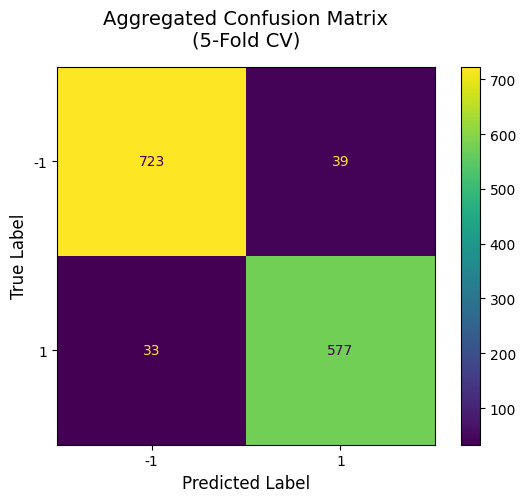

In [9]:
global_cm = np.zeros((2, 2), dtype=int)

for fold in range(1, K_FOLDS + 1):
    # Load test data
    test_csv = f'fold_{fold}/test_data.csv'
    test_df = pd.read_csv(test_csv)
    
    X_test = test_df.drop('target', axis=1).values
    y_test = test_df['target'].values
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    # Init model and load weights
    current_ansatz = ansatz(N_QUBITS, DEPTH)
    model = HybridModel(current_ansatz, N_QUBITS)
    model.load_state_dict(torch.load(f'model_weights_fold_{fold}.pth'))
    model.eval()
    
    # Predict
    with torch.no_grad():
        test_outputs = model(X_test_tensor).numpy()
        
    predicted = np.where(test_outputs > 0, 1, -1).flatten()
    
    # Compute fold CM and add to global CM
    fold_cm = confusion_matrix(y_test, predicted, labels=[-1, 1])
    global_cm += fold_cm

# Plot the aggregated confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=global_cm, display_labels=[-1, 1])

disp.plot(values_format='d', ax=ax, colorbar=True)

# Set titles and labels
plt.title('Aggregated Confusion Matrix\n(5-Fold CV)', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

## 